Training size: (16, 5)
Testing size: (4, 5)

Model Performance:
MSE: 17.554797771119407
RMSE: 4.189844599877113
R² Score: 0.984279578869541

Model Coefficients:
area_sqft: 0.06406942785697443
bedrooms: 6.516580879332708
bathrooms: 7.206969849054046
age_years: 2.1897857038362143
distance_to_city_km: -1.415446590831722
Intercept: -47.82677399473198


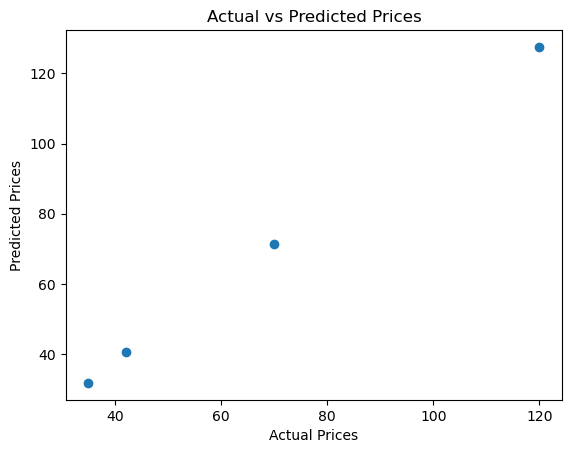

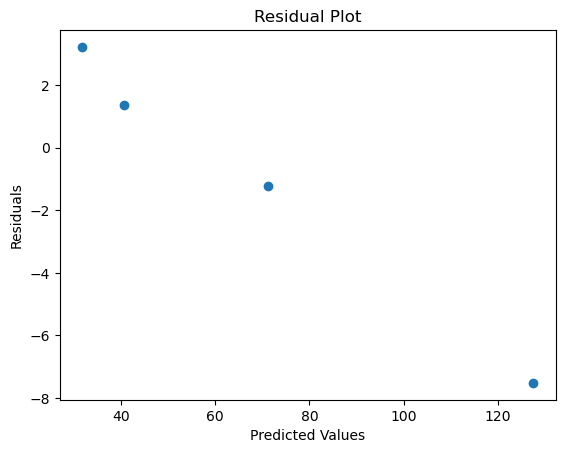

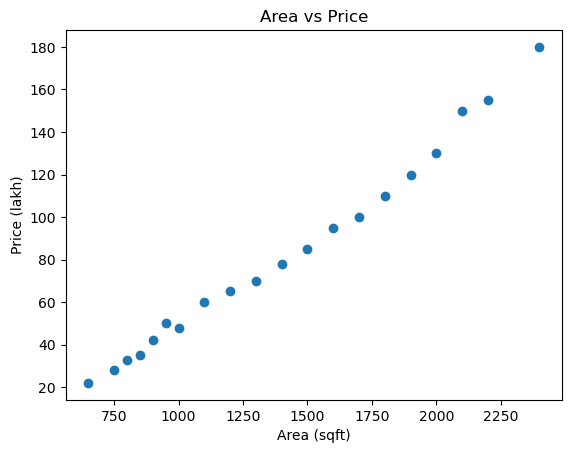

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("house_prices.csv")

# Features and target
X = df[['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']]
y = df['price_lakh']

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# Coefficients
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Intercept:", model.intercept_)

# ------------------ GRAPHS ------------------

# 1. Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# 2. Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 3. Feature vs Price (example: area)
plt.figure()
plt.scatter(df['area_sqft'], df['price_lakh'])
plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")
plt.title("Area vs Price")
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("house_prices.csv")

# Features and target
X = df[['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']]
y = df['price_lakh']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🎯 Polynomial Transformation
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_pred = model.predict(X_test_poly)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nPolynomial Regression Results:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


Polynomial Regression Results:
MSE: 39.06754553079019
RMSE: 6.250403629429878
R² Score: 0.9650147910397581


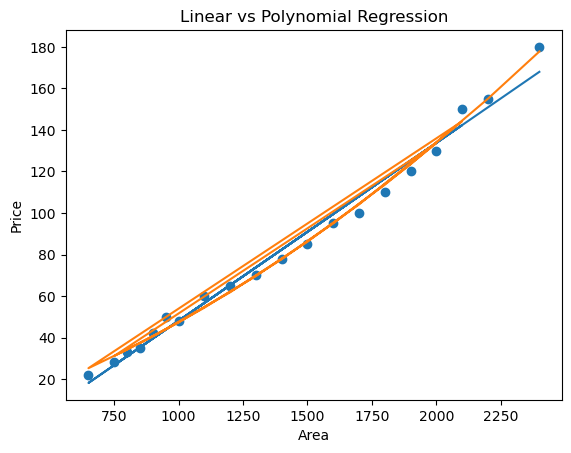

In [3]:
# Visualize using only area for understanding

X_simple = df[['area_sqft']]
y_simple = df['price_lakh']

# Linear
lin_model = LinearRegression()
lin_model.fit(X_simple, y_simple)

# Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_simple)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_simple)

# Plot
plt.figure()
plt.scatter(X_simple, y_simple)

# Linear line
plt.plot(X_simple, lin_model.predict(X_simple))

# Polynomial curve
plt.plot(X_simple, poly_model.predict(X_poly))

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear vs Polynomial Regression")
plt.show()